In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")
df

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754


In [5]:

print(df.head())


   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [6]:
print(df.shape)

(2640, 12)


## Data Preprocessing

In [7]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [8]:
print("\nDuplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


Duplicate Rows: 0



## EDA

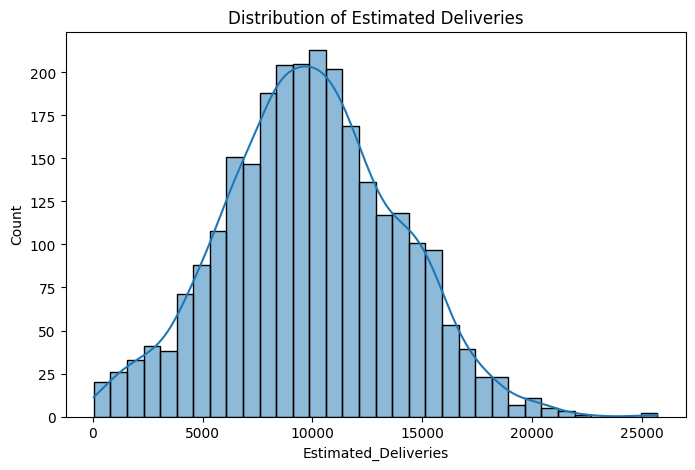

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated_Deliveries"], kde=True)
plt.title("Distribution of Estimated Deliveries")
plt.show()

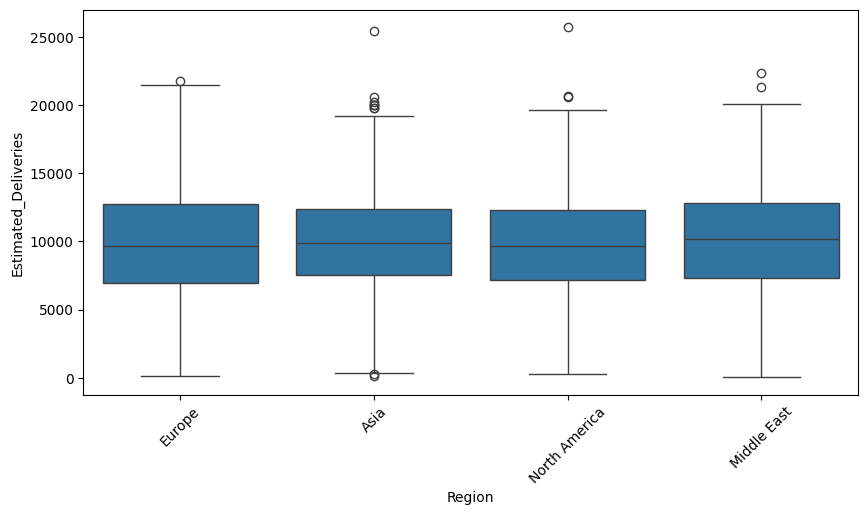

In [10]:
# Deliveries by Region

plt.figure(figsize=(10,5))
sns.boxplot(
    x="Region",
    y="Estimated_Deliveries",
    data=df
)
plt.xticks(rotation=45)
plt.show()


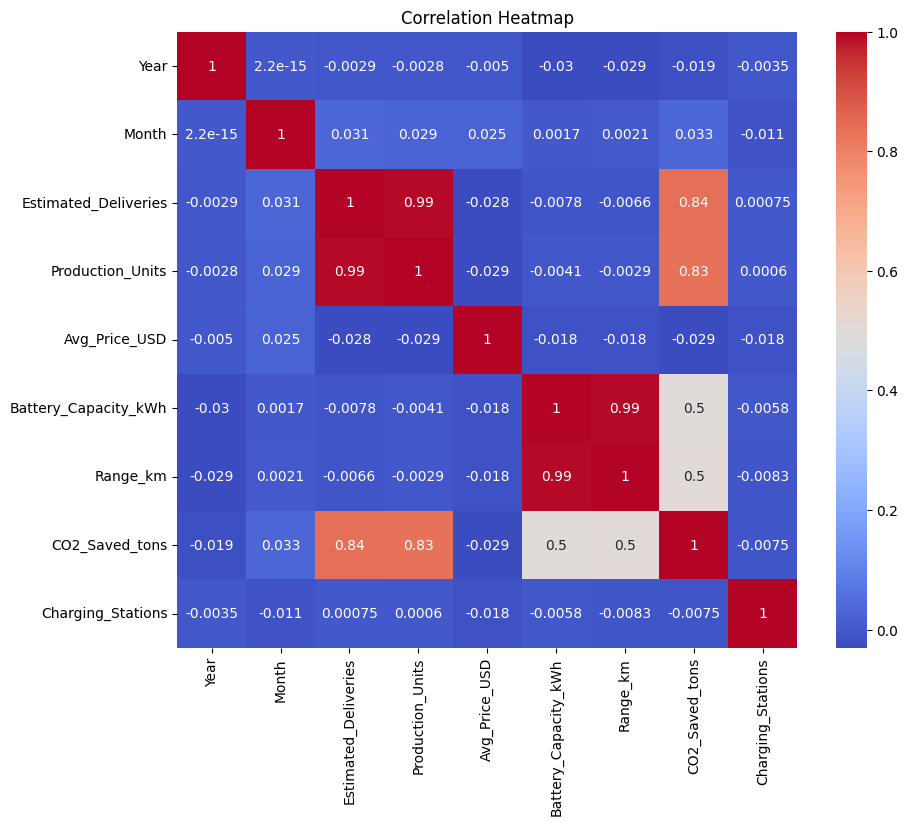

In [11]:
# Correlation Heatmap

numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()


## FEATURE ENGINEERING

In [12]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str)
    + "-"
    + df["Month"].astype(str)
)

In [13]:
df["Price_per_kWh"] = (
    df["Avg_Price_USD"]
    /
    df["Battery_Capacity_kWh"]
)

In [14]:
df["Production_Delivery_Ratio"] = (
    df["Production_Units"]
    /
    df["Estimated_Deliveries"]
)

In [15]:
print(df.head())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations       Date  \
0         1863.42  Interpolated (Month)              12207 2023-05-01   
1          249.46    Official (Quarter)         

In [16]:
target = "Estimated_Deliveries"

X = df.drop(columns=[target, "Date"])

y = df[target]

categorical_cols = X.select_dtypes(include="object").columns

numerical_cols = X.select_dtypes(exclude="object").columns

In [17]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.arima.model import ARIMA


##  PREPROCESSING PIPELINE

In [18]:
preprocessor = ColumnTransformer(
    transformers=[("num",StandardScaler(),numerical_cols),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_cols)
    ]
)


## TRAIN TEST SPLIT

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## RANDOM FOREST MODEL

In [20]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Price_per_kWh', 'Production_Delivery_Ratio'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Region', 'Model', 'Source_Type'], dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [21]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(
    y_test,
    y_pred
)


In [22]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

In [23]:
print("\nModel Performance")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2  :", round(r2,4))



Model Performance
MAE : 67.59
RMSE: 112.11
R2  : 0.9992


## HYPERPARAMETER TUNING

In [24]:
param_grid = {
    "model__n_estimators":[100,200],
    "model__max_depth":[10,20,None],
    "model__min_samples_split":[2,5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nBest Parameters")
print(grid.best_params_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\nTuned Model R2:",
      r2_score(y_test, y_pred))


Best Parameters
{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Tuned Model R2: 0.9991522565423901


In [25]:
rf = best_model.named_steps["model"]

feature_names = (
    numerical_cols.tolist()
)

importance = rf.feature_importances_

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance[:len(feature_names)]
})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Features")
print(feature_df.head(10))



Top Features
                     Feature  Importance
2           Production_Units    0.990284
9  Production_Delivery_Ratio    0.008650
6             CO2_Saved_tons    0.000285
8              Price_per_kWh    0.000160
5                   Range_km    0.000100
7          Charging_Stations    0.000089
3              Avg_Price_USD    0.000087
1                      Month    0.000071
0                       Year    0.000065
4       Battery_Capacity_kWh    0.000017


## TIME SERIES FORECASTING

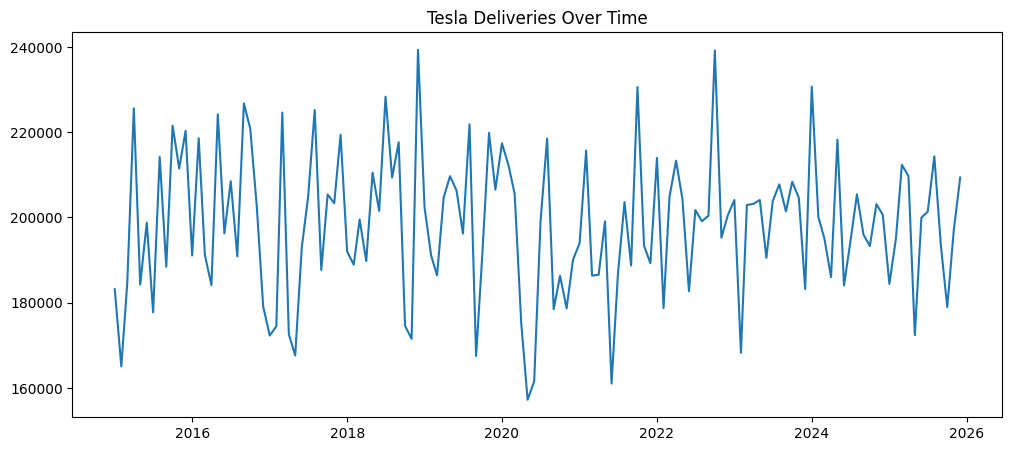

In [26]:
monthly = (
    df.groupby(["Year","Month"])
      ["Estimated_Deliveries"]
      .sum()
      .reset_index()
)

monthly["Date"] = pd.to_datetime(
    monthly["Year"].astype(str)
    + "-"
    + monthly["Month"].astype(str)
)

monthly = monthly.set_index("Date")

series = monthly["Estimated_Deliveries"]

plt.figure(figsize=(12,5))
plt.plot(series)
plt.title("Tesla Deliveries Over Time")
plt.show()

##  ARIMA MODEL

In [27]:
model = ARIMA(
    series,
    order=(5,1,0)
)

model_fit = model.fit()

forecast = model_fit.forecast(
    steps=12
)

print("\nNext 12 Month Forecast")
print(forecast)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



Next 12 Month Forecast
2026-01-01    203819.655294
2026-02-01    202894.176208
2026-03-01    199011.662569
2026-04-01    198667.010481
2026-05-01    200971.493836
2026-06-01    201391.449842
2026-07-01    201412.663909
2026-08-01    201031.409117
2026-09-01    200601.086697
2026-10-01    200710.068210
2026-11-01    200864.721557
2026-12-01    200936.680131
Freq: MS, Name: predicted_mean, dtype: float64


## PLOT FORECAST

/tmp/ipykernel_4326/4102752702.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(


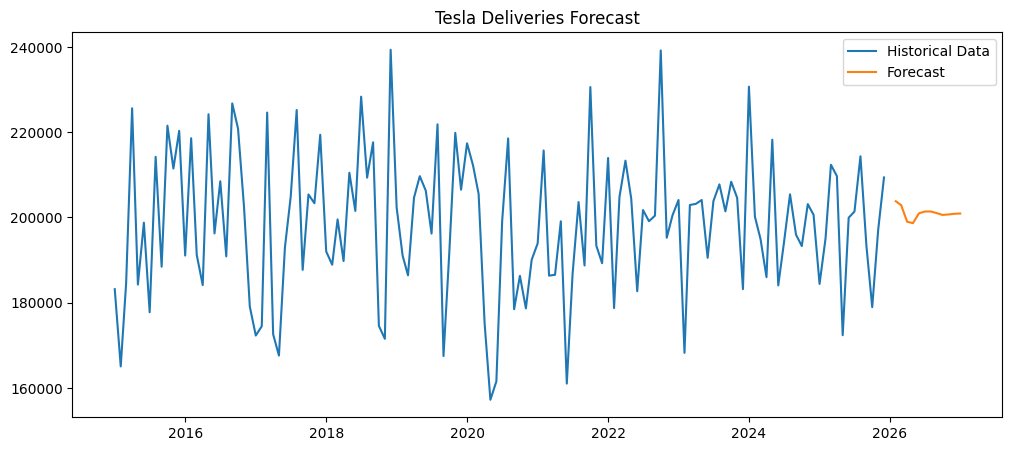

In [28]:
plt.figure(figsize=(12,5))

plt.plot(
    series,
    label="Historical Data"
)

forecast_index = pd.date_range(
    start=series.index[-1],
    periods=13,
    freq="M"
)[1:]

plt.plot(
    forecast_index,
    forecast,
    label="Forecast"
)

plt.legend()
plt.title("Tesla Deliveries Forecast")
plt.show()